Graph Statistics
 
Nodes: 1000
Edges: 2068
Number of cycles detected: 1081


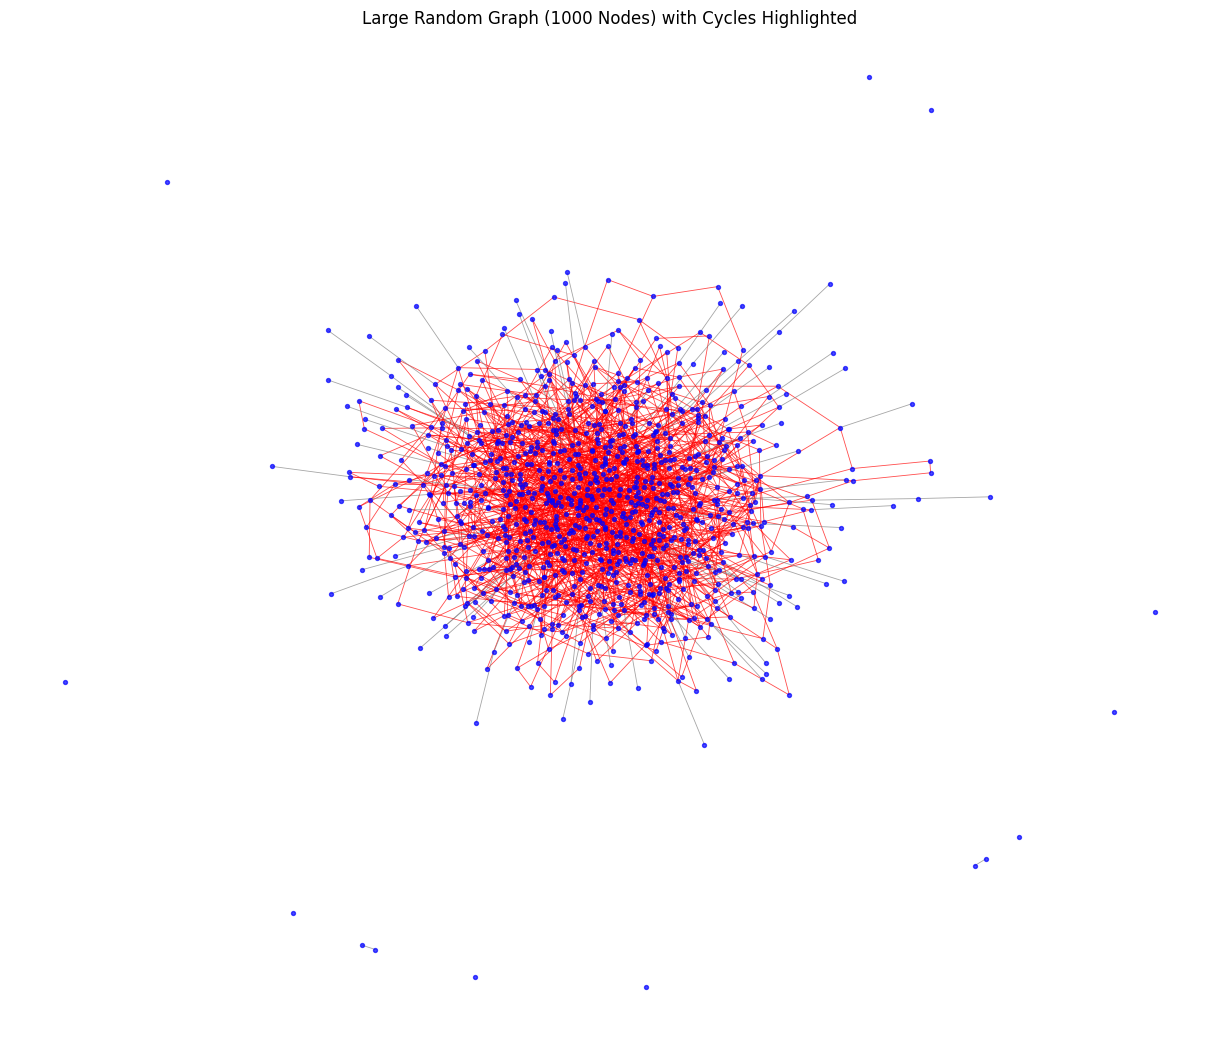

In [2]:
import networkx as nx
import random
import matplotlib.pyplot as plt
# 1. Generate a large random graph
n_nodes = 1000
n_edges = 2000
G = nx.gnm_random_graph(n_nodes, n_edges)
# 2. Add guaranteed cycles
num_cycles = 10
for _ in range(num_cycles):
    cycle_len = random.randint(3, 10)
    cycle_nodes = random.sample(range(n_nodes),
                                 cycle_len) # for i in range(cycle_len):
    for i in range(cycle_len):
        G.add_edge(cycle_nodes[i], cycle_nodes[(i + 1) % cycle_len])
# 3. Detect cycles
cycles = nx.cycle_basis(G)
print("Graph Statistics")
print(" ")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Number of cycles detected:", len(cycles))
# 4. Identify cycle edges
cycle_edges = set()
for cycle in cycles:
    for i in range(len(cycle)):
        edge = tuple(sorted((cycle[i], cycle[(i + 1) % len(cycle)])))
        cycle_edges.add(edge)
# 5. Assign edge colors
edge_colors = []
for edge in G.edges():
    if tuple(sorted(edge)) in cycle_edges:
        edge_colors.append("red")  # cycle edges
    else:
        edge_colors.append("gray")
# 6. Compute layout (optimized)
pos = nx.spring_layout(G, seed=42, iterations=50)
# 7. Draw graph
plt.figure(figsize=(12, 10))
nx.draw(
    G, pos,
    node_size=8,
    node_color="blue",
    edge_color=edge_colors,
    alpha=0.7,
    width=0.6
)
plt.title("Large Random Graph (1000 Nodes) with Cycles Highlighted")
plt.show()